<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/ML/LinearRegression_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [6]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({
    "area": area.round(1),
    "rooms": rooms.astype(int),
    "floor": floor,
    "dist_km": dist_km.round(1),
    "age_years": age_years,
    "price": price.round(1),
})

df.head()


,area,rooms,floor,dist_km,age_years,price
0,55.0,1,4,2.6,25,141.0
1,72.1,2,14,7.9,39,176.6
2,80.4,4,6,7.2,41,165.8
3,83.8,3,8,0.7,50,183.1
4,47.7,2,24,0.5,34,126.1


In [11]:
len(df)
print(df.shape[0], df.shape[1])

1000 6


In [12]:
print("Пропуски - ", df.isna().sum().sum())
#

Пропуски -  0


In [14]:
df.describe()

,area,rooms,floor,dist_km,age_years,price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,59.787100,2.449000,12.371000,5.077700,30.051000,134.833200
std,20.048231,0.978957,7.045211,4.906813,17.194594,45.173629
min,20.000000,1.000000,1.000000,0.300000,0.000000,20.000000
25%,46.250000,2.000000,6.000000,1.475000,15.000000,103.600000
50%,59.400000,2.000000,12.500000,3.550000,31.000000,135.950000
75%,73.325000,3.000000,18.000000,7.200000,44.000000,165.525000
max,122.600000,5.000000,24.000000,25.000000,59.000000,278.700000


Text(0.5, 1.0, 'Залежність ціни від площі')

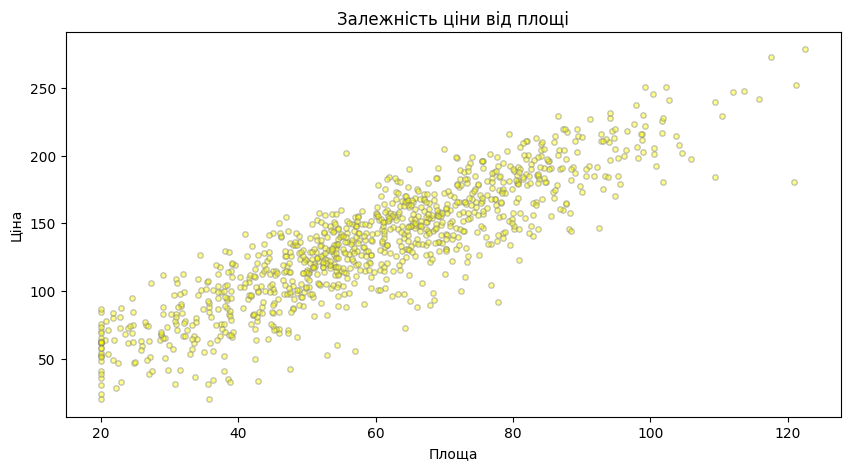

In [27]:

fig = plt.figure(figsize=(10, 5))
plt.scatter(df["area"], df["price"], edgecolors="grey", color="yellow", alpha=0.46, s=15)
plt.xlabel("Площа")
plt.ylabel("Ціна")
plt.title("Залежність ціни від площі")
plt.leyaut




In [30]:
df.columns

Index(['area', 'rooms', 'floor', 'dist_km', 'age_years', 'price'], dtype='object')

In [33]:
X = df[['area', 'rooms', 'floor', 'dist_km', 'age_years', 'price']] # features
y = df["price"] # target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
print("Навчальна вибірка", X_train.shape, "\n", "Тестова вибірка", X_test.shape)

Навчальна вибірка (800, 6) 
 Тестова вибірка (200, 6)
